# Trace Count v6: Separator Trace, No Numeric Indices

v6 copies the controlled v2 marker-trace experiment, but removes numeric trace indices from the thinking trace.

```text
v2 thinking trace: <Think/> <1> <A> <2> <B> <3> <C> </Think> <Ans> <3>
v6 thinking trace: <Think/> <Sep> <A> <Sep> <B> <Sep> <C> </Think> <Ans> <3>
```

The final-answer metric still checks only the numeric token after `<Ans>`. The core question is whether separator-trace thinking still learns item-specific retrieval/counting once explicit prefix-count tokens are gone.


## 1. Environment and Repo Setup


In [1]:
from pathlib import Path
import os
import platform
import shutil
import subprocess
import sys
from datetime import datetime

REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
REPO_DIR = Path("/content/Synthetic_CoT_NiaH_Count")
PULL_REPO = True
REPAIR_NUMPY_ABI = True
INSTALL_MINIMAL_DEPS = False
INSTALL_EDITABLE_PACKAGE = False

if Path("/content").exists():
    if REPO_DIR.exists():
        os.chdir(REPO_DIR)
        if PULL_REPO and (REPO_DIR / ".git").exists():
            subprocess.run(["git", "pull"], check=False)
    else:
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
        os.chdir(REPO_DIR)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from scripts.colab_setup import setup_colab

ROOT = setup_colab(
    repo_url=REPO_URL,
    repo_dir=REPO_DIR,
    pull=False,
    repair_numpy_abi=REPAIR_NUMPY_ABI,
    install_deps=INSTALL_MINIMAL_DEPS,
    install_editable=INSTALL_EDITABLE_PACKAGE,
)

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("cwd:", Path.cwd())
print("python:", sys.executable)
print("platform:", platform.platform())
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


numpy=2.0.2 pandas=2.2.2 scipy=1.16.3
cwd = /content/Synthetic_CoT_NiaH_Count
Dependency import check passed.
cwd: /content/Synthetic_CoT_NiaH_Count
python: /usr/bin/python3
platform: Linux-6.6.122+-x86_64-with-glibc2.35
torch: 2.11.0+cu128
cuda: True
gpu: NVIDIA A100-SXM4-40GB


## 2. Runtime Settings

Use `debug` first for an end-to-end sanity check. For the real v6 run, set `PRESET = "main"`.

`RUN_PROBES` and `RUN_ATTENTION` can be turned off for a faster first pass, then rerun later with `STAGE = "probes"` or `STAGE = "attention"` after checkpoints exist.


In [2]:
PRESET = "main"  # "debug" or "main"
STAGE = "all"      # "all", "train", "final_eval", "probes", "attention", "plots", "report"
CONFIG = f"synthetic_counting_v6/configs/{PRESET}.yaml"
RUN_DIR = f"runs/v6_separator_trace_{PRESET}_seed1234"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SKIP_COMPLETED = True
RUN_PROBES = True
RUN_ATTENTION = True

# Optional overrides. Leave as None to use YAML defaults.
TRAIN_STEPS = None
BATCH_SIZE = None
VAL_EXAMPLES_PER_COUNT = None
TEST_EXAMPLES_PER_COUNT = None
PROBE_EXAMPLES_PER_COUNT = None
ATTENTION_EXAMPLES_PER_COUNT = None

settings = {
    "PRESET": PRESET,
    "STAGE": STAGE,
    "CONFIG": CONFIG,
    "RUN_DIR": RUN_DIR,
    "DEVICE": DEVICE,
    "SKIP_COMPLETED": SKIP_COMPLETED,
    "RUN_PROBES": RUN_PROBES,
    "RUN_ATTENTION": RUN_ATTENTION,
}
settings


{'PRESET': 'main',
 'STAGE': 'all',
 'CONFIG': 'synthetic_counting_v6/configs/main.yaml',
 'RUN_DIR': 'runs/v6_separator_trace_main_seed1234',
 'DEVICE': 'cuda',
 'SKIP_COMPLETED': True,
 'RUN_PROBES': True,
 'RUN_ATTENTION': True}

## 3. Run v6 Pipeline


In [3]:
cmd = [
    sys.executable,
    "-u",
    "-m",
    "synthetic_counting_v6.run_v6_experiment",
    "--config",
    CONFIG,
    "--stage",
    STAGE,
    "--run-dir",
    RUN_DIR,
    "--device",
    DEVICE,
]
if SKIP_COMPLETED:
    cmd.append("--skip-completed")
if not RUN_PROBES:
    cmd.append("--no-probes")
if not RUN_ATTENTION:
    cmd.append("--no-attention")
for flag, value in [
    ("--train-steps", TRAIN_STEPS),
    ("--batch-size", BATCH_SIZE),
    ("--val-examples-per-count", VAL_EXAMPLES_PER_COUNT),
    ("--test-examples-per-count", TEST_EXAMPLES_PER_COUNT),
    ("--probe-examples-per-count", PROBE_EXAMPLES_PER_COUNT),
    ("--attention-examples-per-count", ATTENTION_EXAMPLES_PER_COUNT),
]:
    if value is not None:
        cmd += [flag, str(value)]

print(" ".join(cmd), flush=True)
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
captured = []
for line in proc.stdout:
    print(line, end="")
    captured.append(line.rstrip())
returncode = proc.wait()
if returncode:
    print("---- Last 160 log lines ----")
    print("\n".join(captured[-160:]))
    raise subprocess.CalledProcessError(returncode, cmd)

FINAL_RUN_DIR = Path(RUN_DIR)
FINAL_REPORT = FINAL_RUN_DIR / "report" / "report.html"
for line in reversed(captured):
    if line.startswith("FINAL_RUN_DIR "):
        FINAL_RUN_DIR = Path(line.split(" ", 1)[1].strip())
    if line.startswith("FINAL_REPORT "):
        FINAL_REPORT = Path(line.split(" ", 1)[1].strip())
print("FINAL_RUN_DIR =", FINAL_RUN_DIR)
print("FINAL_REPORT =", FINAL_REPORT)


/usr/bin/python3 -u -m synthetic_counting_v6.run_v6_experiment --config synthetic_counting_v6/configs/main.yaml --stage all --run-dir runs/v6_separator_trace_main_seed1234 --device cuda --skip-completed
[v6] stage=train

v6 training: 100%|██████████| 20000/20000 [1:36:13<00:00,  3.46it/s, lr=1.95e-12, non=0.0000, sep=0.0000]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 56.74it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 63.95it/s]
[v6] stage=final_eval

Loading weights: 100%|██████████| 52/52 [00:00<00:00, 6096.03it/s]

Loading weights: 100%|██████████| 52/52 [00:00<00:00, 6197.72it/s]
[v6] stage=probes

probe cache non_thinking train:  99%|█████████▊| 78/79 [00:03<00:00, 22.44it/s]
                                                                               

probe cache thinking_sep_trace train:  99%|█████████▊| 78/79 [00:26<00:00,  2.95it/s]
                                                                                     

probe cache non_thinking

## 4. Result Tables

Accuracy here always means exact match of the final numeric count token after `<Ans>`. For `thinking_sep_trace / generated_trace`, the model must first generate the `<Sep> marker ... </Think> <Ans>` suffix by itself; for `oracle_trace_final_readout`, the gold separator trace is provided and only final answer readout is tested.


In [4]:
RUN_DIR_PATH = Path(FINAL_RUN_DIR) if "FINAL_RUN_DIR" in globals() else Path(RUN_DIR)
metrics_dir = RUN_DIR_PATH / "metrics"

for filename in ["metrics_train.csv", "metrics_eval_by_bin.csv", "metrics_eval_by_count.csv", "metrics_final_test_by_bin.csv", "metrics_final_test_by_count.csv"]:
    path = metrics_dir / filename
    if path.exists():
        display(Markdown(f"**{filename}**"))
        df = pd.read_csv(path)
        display(df.tail(20))
    else:
        display(Markdown(f"Missing `{path}`"))


**metrics_train.csv**

,step,model_type,train_loss,train_completion_loss,train_trace_loss,train_final_answer_loss,learning_rate
782,19550,non_thinking,2.328306e-09,2.328306e-09,NaN,0.0,3.957800e-07
783,19550,thinking_sep_trace,4.936950e-09,4.936950e-09,4.936950e-09,0.0,3.957800e-07
784,19600,non_thinking,2.793968e-09,2.793968e-09,NaN,0.0,3.129172e-07
785,19600,thinking_sep_trace,4.370584e-09,4.370584e-09,4.370584e-09,0.0,3.129172e-07
786,19650,non_thinking,1.862645e-09,1.862645e-09,NaN,0.0,2.397675e-07
787,19650,thinking_sep_trace,5.103940e-09,5.103940e-09,5.103940e-09,0.0,2.397675e-07
788,19700,non_thinking,2.328306e-09,2.328306e-09,NaN,0.0,1.763355e-07
789,19700,thinking_sep_trace,4.388072e-09,4.388072e-09,4.388072e-09,0.0,1.763355e-07
790,19750,non_thinking,3.259629e-09,3.259629e-09,NaN,0.0,1.226253e-07
791,19750,thinking_sep_trace,4.814690e-09,4.814690e-09,4.814690e-09,0.0,1.226253e-07


**metrics_eval_by_bin.csv**

,step,model_type,eval_mode,count_bin,accuracy,invalid_rate,eval_completion_loss,eval_trace_loss,eval_final_answer_loss,mae,under_rate,over_rate,trace_exact_match_rate,trace_marker_precision,trace_marker_recall,trace_delimiter_count_accuracy,premature_close_rate,missing_close_rate,ans_generated_rate,think_close_generated_rate,n_examples
349,19000,thinking_sep_trace,oracle_trace_final_readout,low,1.0,0.0,7.175737e-09,1.225207e-08,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,600
350,19000,thinking_sep_trace,oracle_trace_final_readout,mid,1.0,0.0,3.502955e-09,4.071672e-09,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,600
351,19500,non_thinking,direct,high,1.0,0.0,2.011657e-09,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800
352,19500,non_thinking,direct,low,1.0,0.0,3.178914e-09,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600
353,19500,non_thinking,direct,mid,1.0,0.0,4.669030e-09,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600
354,19500,thinking_sep_trace,generated_trace,high,1.0,0.0,4.468918e-09,5.078376e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,800
355,19500,thinking_sep_trace,generated_trace,low,1.0,0.0,7.395943e-09,1.279324e-08,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,600
356,19500,thinking_sep_trace,generated_trace,mid,1.0,0.0,3.366361e-09,3.876231e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,600
357,19500,thinking_sep_trace,oracle_trace_final_readout,high,1.0,0.0,4.468918e-09,5.078376e-09,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,800
358,19500,thinking_sep_trace,oracle_trace_final_readout,low,1.0,0.0,7.395943e-09,1.279324e-08,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,600


**metrics_eval_by_count.csv**

,step,model_type,eval_mode,count,accuracy,invalid_rate,eval_completion_loss,eval_trace_loss,eval_final_answer_loss,mae,under_rate,over_rate,trace_exact_match_rate,trace_marker_precision,trace_marker_recall,trace_delimiter_count_accuracy,premature_close_rate,missing_close_rate,ans_generated_rate,think_close_generated_rate,n_examples
1210,20000,thinking_sep_trace,generated_trace,1,1.0,0.0,1.539787e-08,2.980232e-08,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1211,20000,thinking_sep_trace,generated_trace,2,1.0,0.0,4.768371e-09,6.079673e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1212,20000,thinking_sep_trace,generated_trace,3,1.0,0.0,2.145767e-09,2.299036e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1213,20000,thinking_sep_trace,generated_trace,4,1.0,0.0,2.533197e-09,3.112687e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1214,20000,thinking_sep_trace,generated_trace,5,1.0,0.0,4.427773e-09,4.985115e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1215,20000,thinking_sep_trace,generated_trace,6,1.0,0.0,3.390014e-09,3.851377e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1216,20000,thinking_sep_trace,generated_trace,7,1.0,0.0,3.708733e-09,4.053116e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1217,20000,thinking_sep_trace,generated_trace,8,1.0,0.0,4.291534e-09,4.908617e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1218,20000,thinking_sep_trace,generated_trace,9,1.0,0.0,4.416162e-09,5.113451e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200
1219,20000,thinking_sep_trace,generated_trace,10,1.0,0.0,5.612770e-09,6.414595e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,200


**metrics_final_test_by_bin.csv**

,step,model_type,eval_mode,count_bin,accuracy,invalid_rate,eval_completion_loss,eval_trace_loss,eval_final_answer_loss,mae,under_rate,over_rate,trace_exact_match_rate,trace_marker_precision,trace_marker_recall,trace_delimiter_count_accuracy,premature_close_rate,missing_close_rate,ans_generated_rate,think_close_generated_rate,n_examples
0,20000,non_thinking,direct,high,1.0,0.0,1.847744e-09,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4000
1,20000,non_thinking,direct,low,1.0,0.0,3.715356e-09,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000
2,20000,non_thinking,direct,mid,1.0,0.0,4.847844e-09,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000
3,20000,thinking_sep_trace,generated_trace,high,1.0,0.0,4.603999e-09,5.172939e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,4000
4,20000,thinking_sep_trace,generated_trace,low,1.0,0.0,7.891654e-09,1.355391e-08,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,3000
5,20000,thinking_sep_trace,generated_trace,mid,1.0,0.0,3.215221e-09,3.640190e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,3000
6,20000,thinking_sep_trace,oracle_trace_final_readout,high,1.0,0.0,4.603999e-09,5.172939e-09,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,4000
7,20000,thinking_sep_trace,oracle_trace_final_readout,low,1.0,0.0,7.891654e-09,1.355391e-08,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,3000
8,20000,thinking_sep_trace,oracle_trace_final_readout,mid,1.0,0.0,3.215221e-09,3.640190e-09,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,3000


**metrics_final_test_by_count.csv**

,step,model_type,eval_mode,count,accuracy,invalid_rate,eval_completion_loss,eval_trace_loss,eval_final_answer_loss,mae,under_rate,over_rate,trace_exact_match_rate,trace_marker_precision,trace_marker_recall,trace_delimiter_count_accuracy,premature_close_rate,missing_close_rate,ans_generated_rate,think_close_generated_rate,n_examples
10,20000,thinking_sep_trace,generated_trace,1,1.0,0.0,1.651049e-08,3.202756e-08,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
11,20000,thinking_sep_trace,generated_trace,2,1.0,0.0,4.887581e-09,6.318092e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
12,20000,thinking_sep_trace,generated_trace,3,1.0,0.0,2.276897e-09,2.316066e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
13,20000,thinking_sep_trace,generated_trace,4,1.0,0.0,2.394120e-09,2.622604e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
14,20000,thinking_sep_trace,generated_trace,5,1.0,0.0,3.772122e-09,4.345720e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
15,20000,thinking_sep_trace,generated_trace,6,1.0,0.0,3.479421e-09,3.952246e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
16,20000,thinking_sep_trace,generated_trace,7,1.0,0.0,4.086229e-09,4.434585e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
17,20000,thinking_sep_trace,generated_trace,8,1.0,0.0,4.309416e-09,4.733310e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
18,20000,thinking_sep_trace,generated_trace,9,1.0,0.0,4.790046e-09,5.546369e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000
19,20000,thinking_sep_trace,generated_trace,10,1.0,0.0,5.230307e-09,5.977494e-09,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1000


## 5. Figures

Each figure caption names the x-axis, y-axis, and group definition. The most important behavioral comparison is final-count accuracy for `non_thinking / direct`, `thinking_sep_trace / generated_trace`, and `thinking_sep_trace / oracle_trace_final_readout`.


**plots/train_loss_vs_step.png**  
x = training step; y = masked completion loss. Non-thinking supervises only final answer/EOS; separator-thinking supervises trace + final answer, so raw completion loss lengths differ.

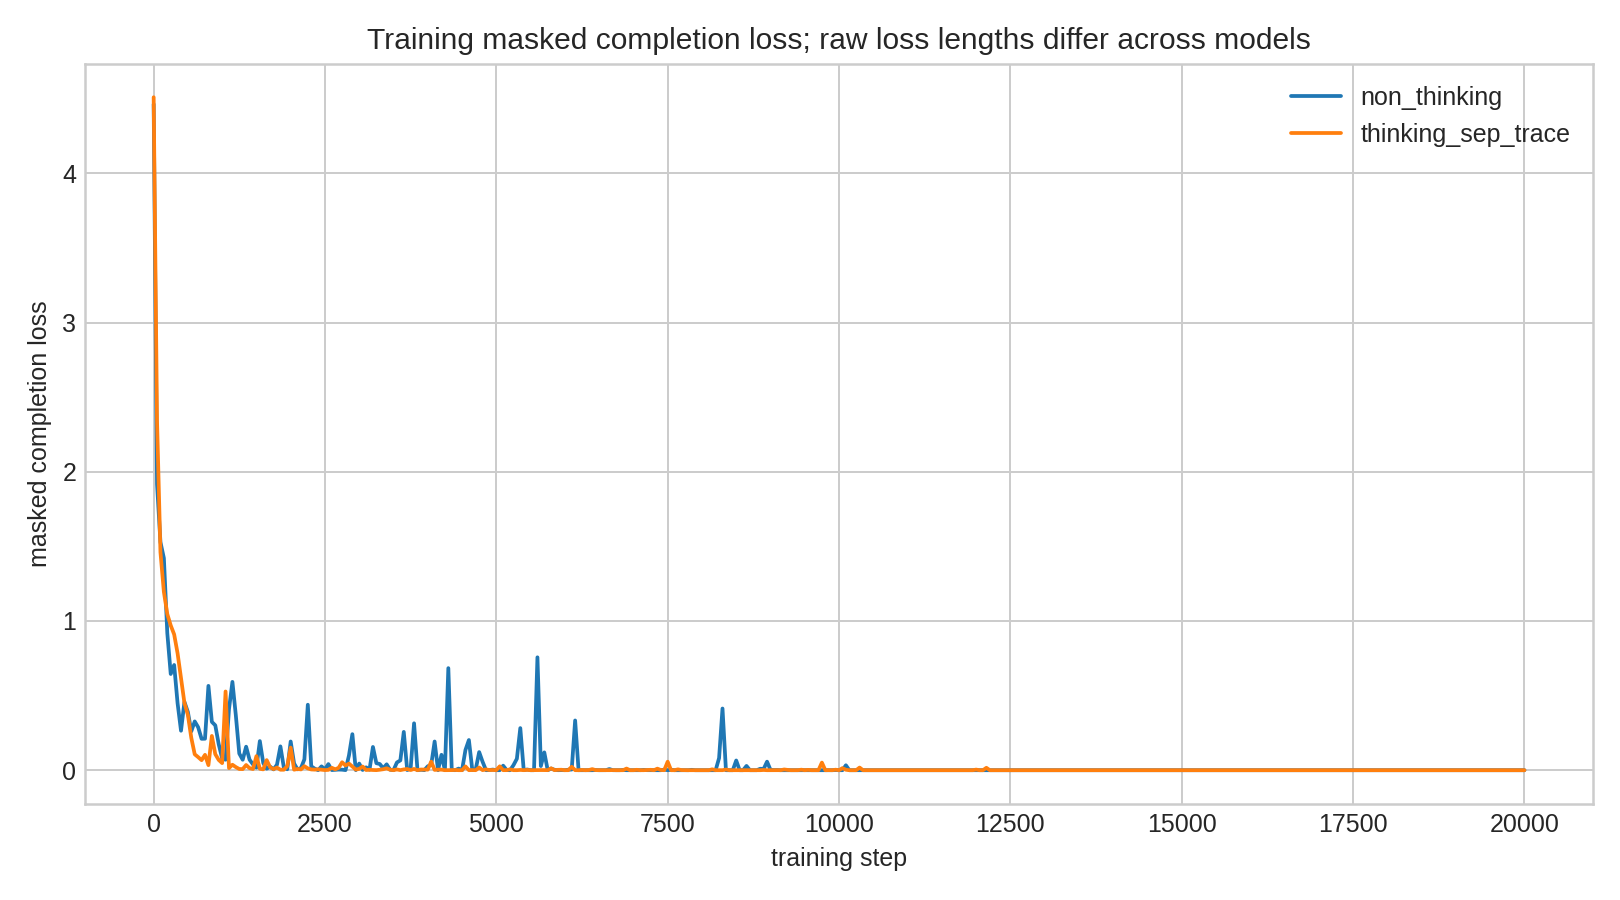

**plots/eval_final_answer_loss_vs_step.png**  
x = training step; y = final-answer cross-entropy restricted to numeric answer tokens. This is the most comparable loss curve.

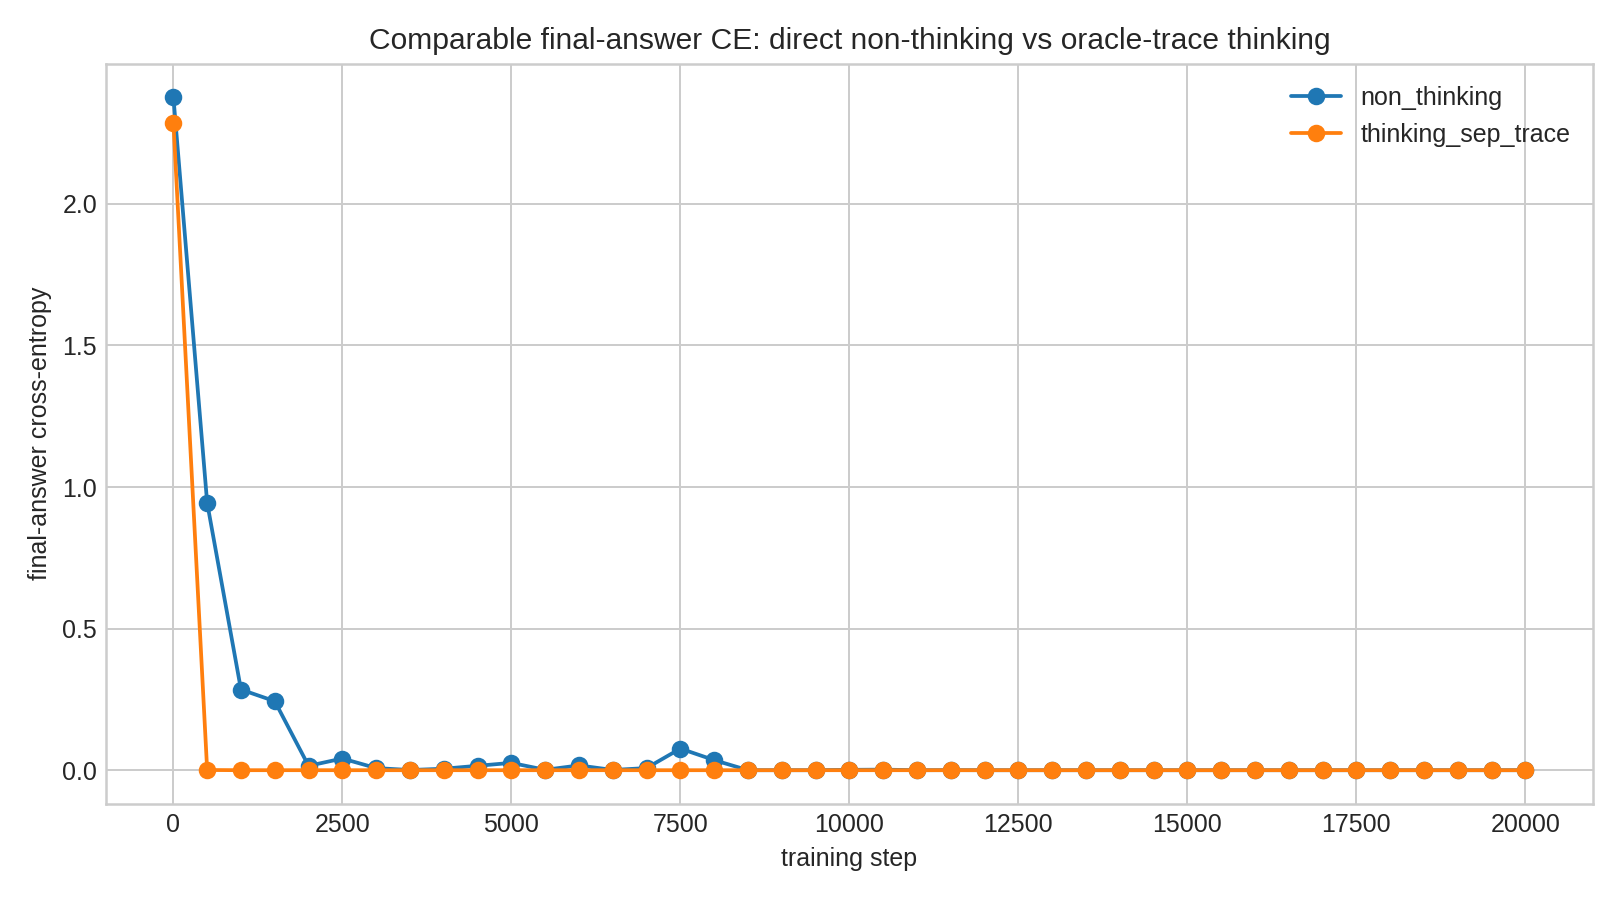

**plots/eval_accuracy_by_bin_vs_step.png**  
x = training step; y = exact final-count accuracy. Groups are model/eval mode/count bin: low=1-3, mid=4-6, high=7-10.

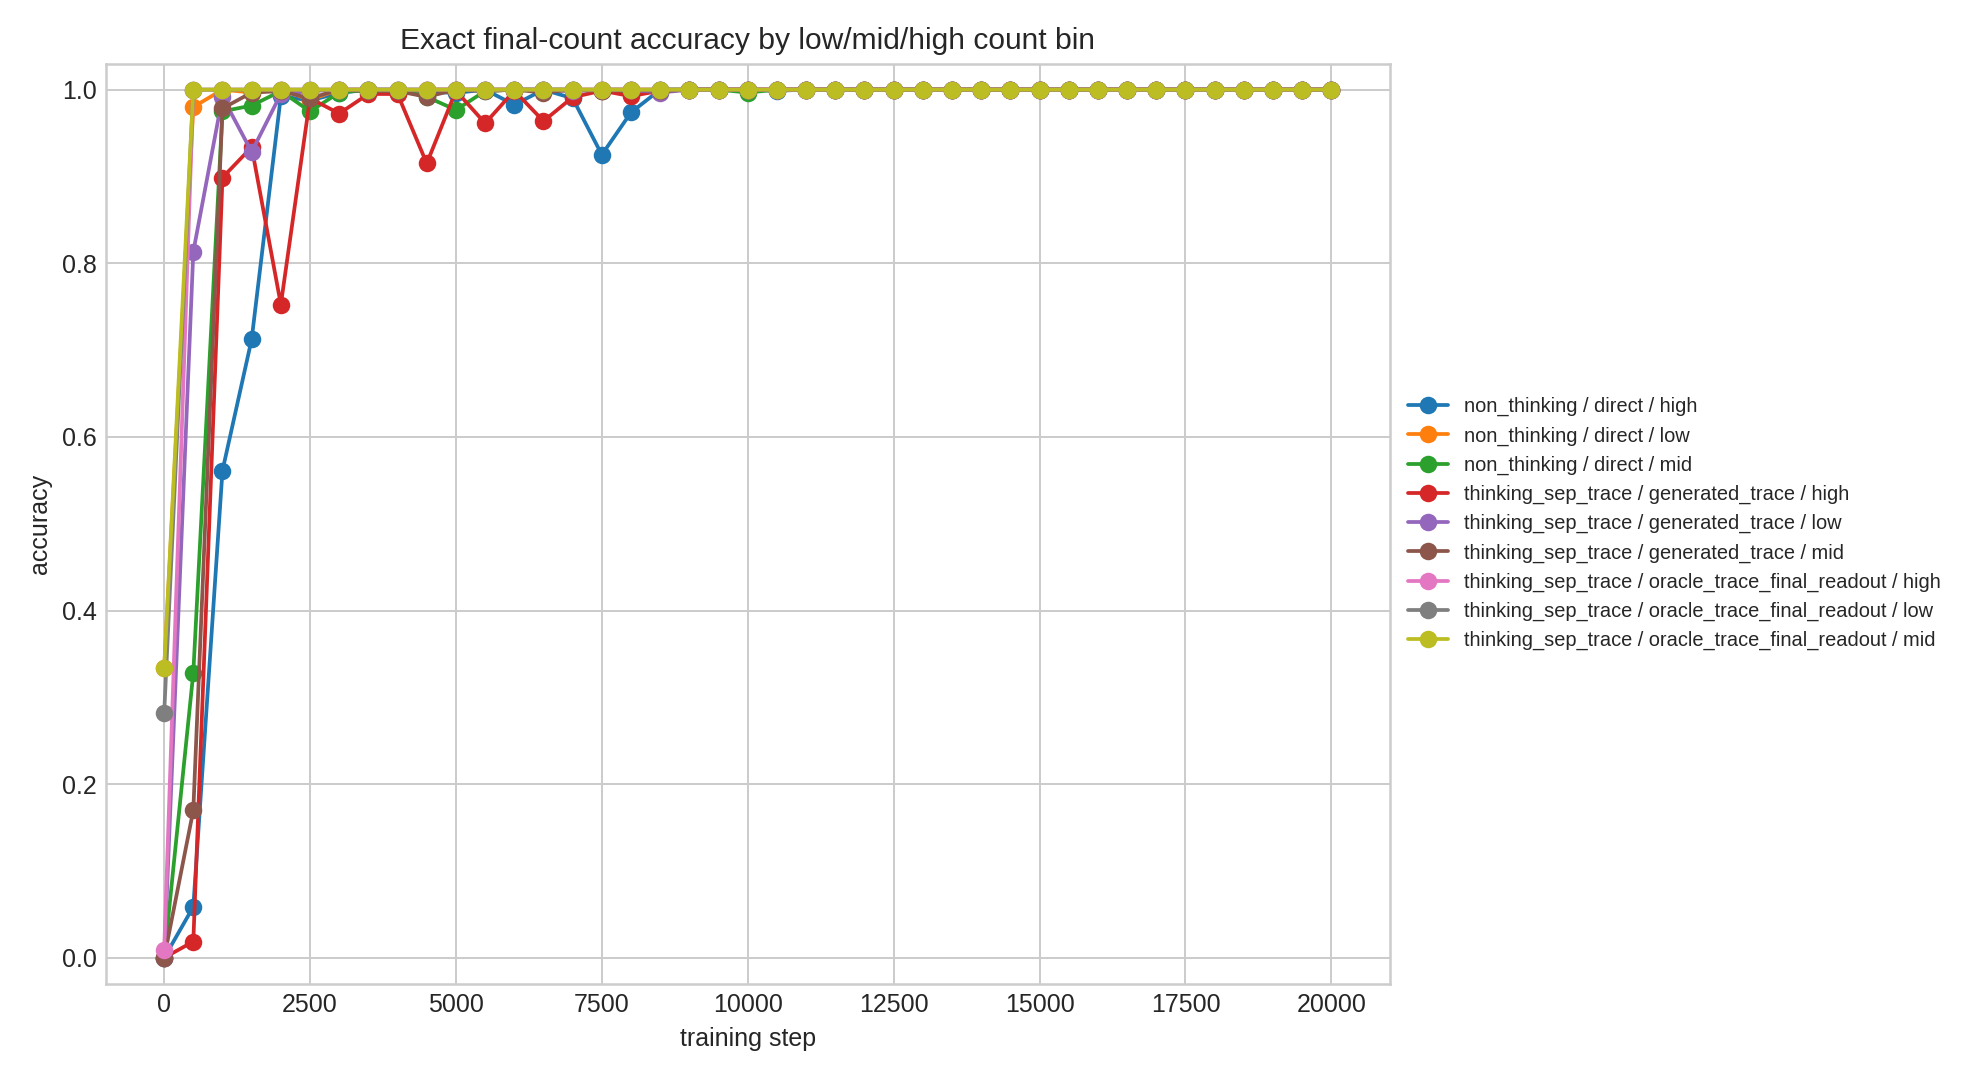

**plots/final_accuracy_by_count.png**  
x = gold count 1-10; y = exact final-count accuracy at final checkpoint. Groups compare direct non-thinking, generated separator trace, and oracle trace readout.

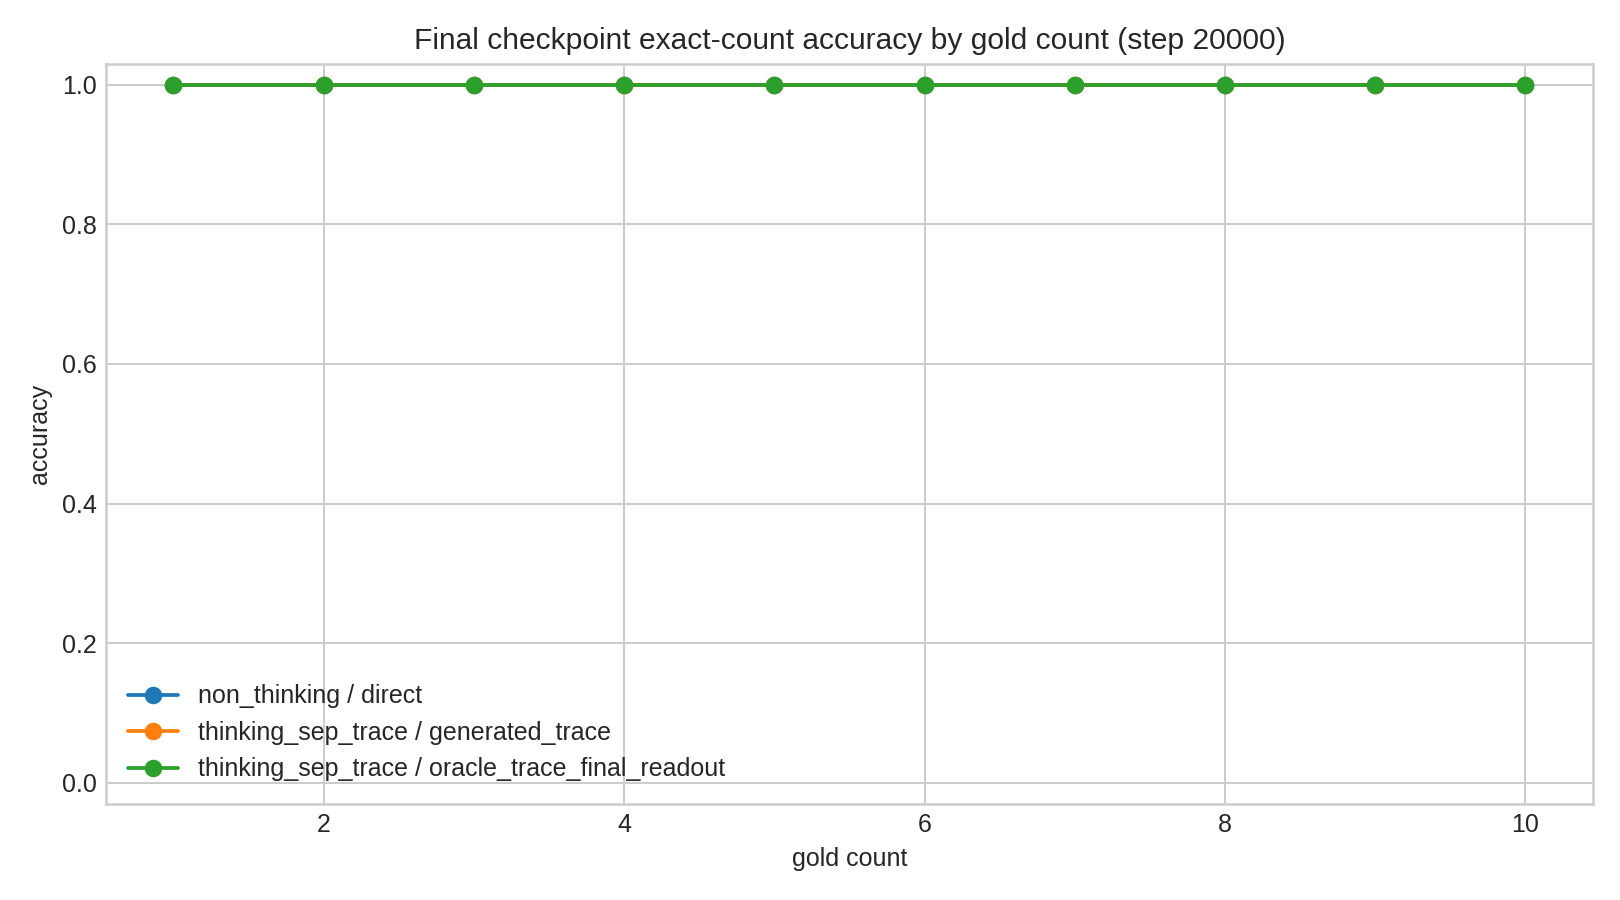

**plots/accuracy_heatmap_by_count_and_step_non_thinking.png**  
Non-thinking heatmap: x = training step, y = gold count, color = exact final-count accuracy.

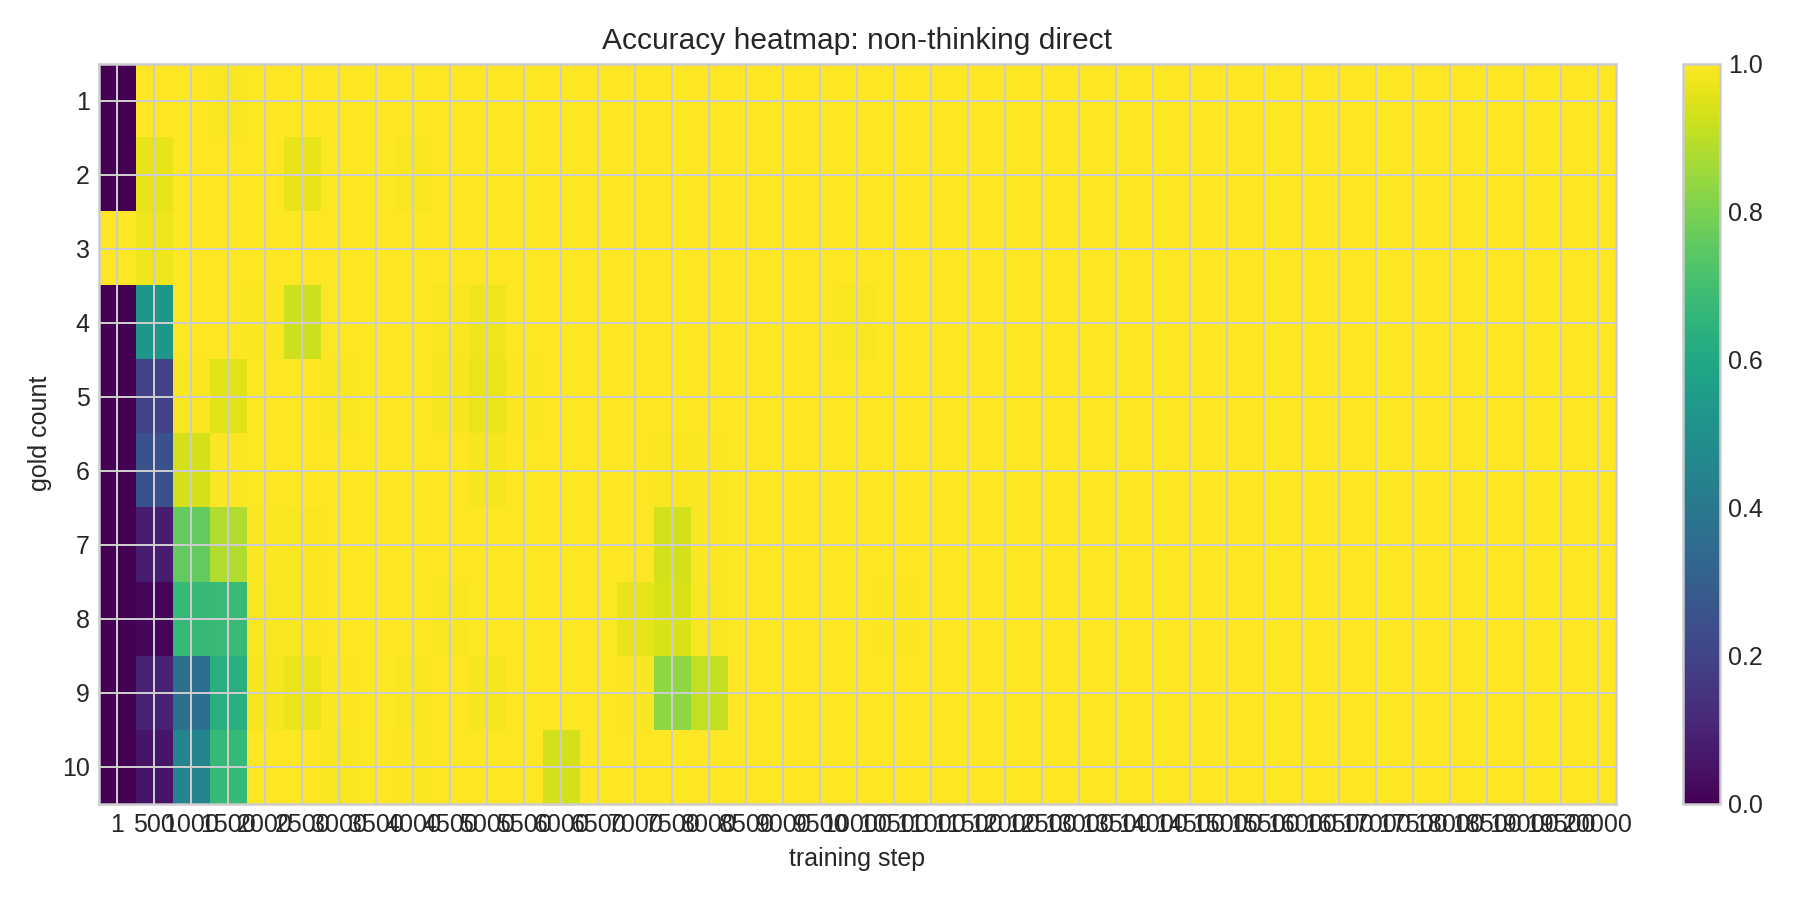

**plots/accuracy_heatmap_by_count_and_step_thinking_generated_trace.png**  
Generated separator trace heatmap: x = training step, y = gold count, color = exact final-count accuracy after free generation.

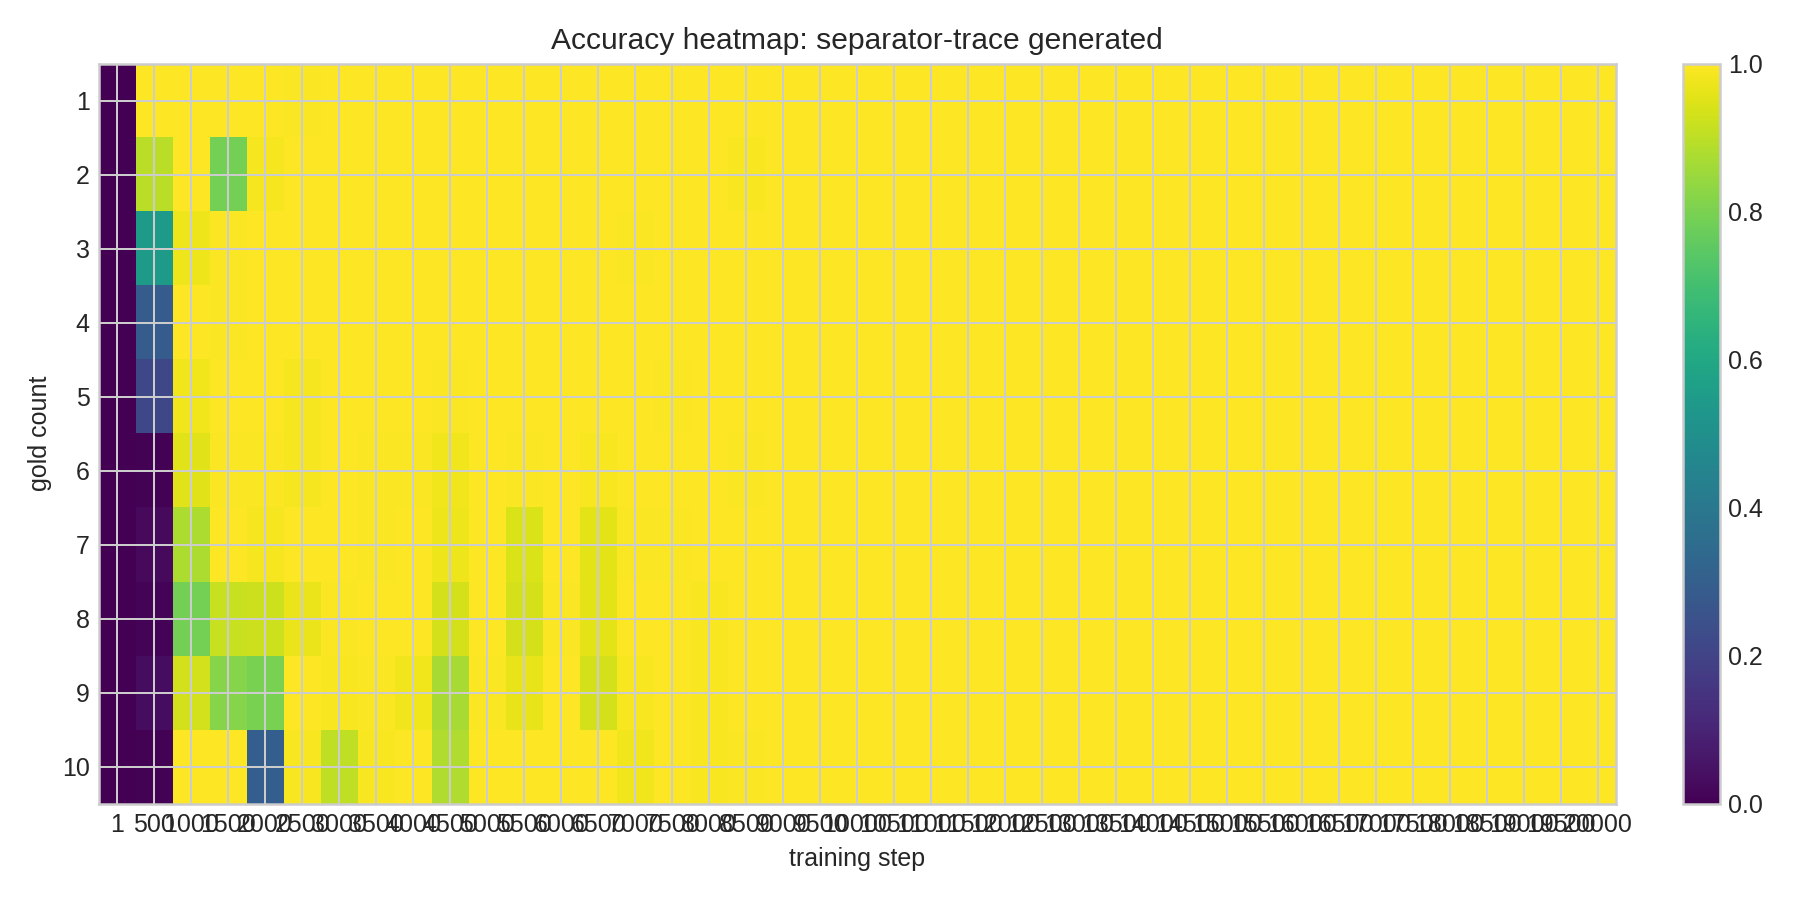

**plots/accuracy_heatmap_by_count_and_step_thinking_oracle_trace.png**  
Oracle separator trace heatmap: x = training step, y = gold count, color = final readout accuracy when gold trace is supplied.

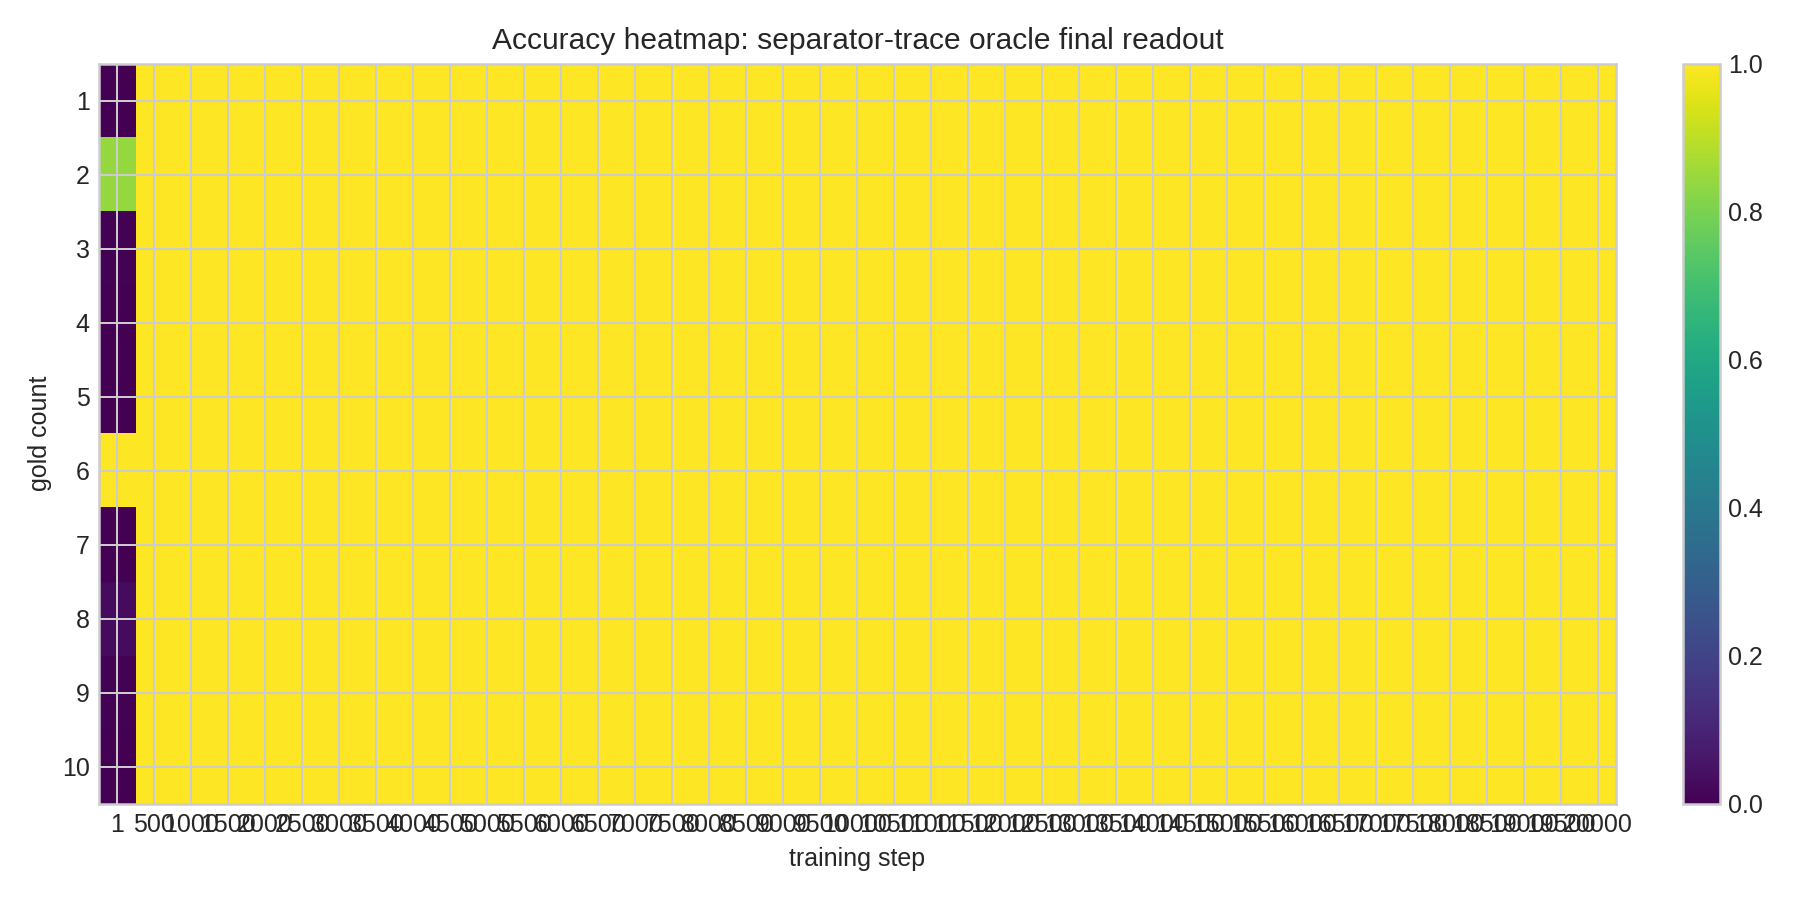

**plots/trace_exact_by_count.png**  
x = gold count; y = rate that generated trace exactly equals `<Sep> marker_1 ... <Sep> marker_n`.

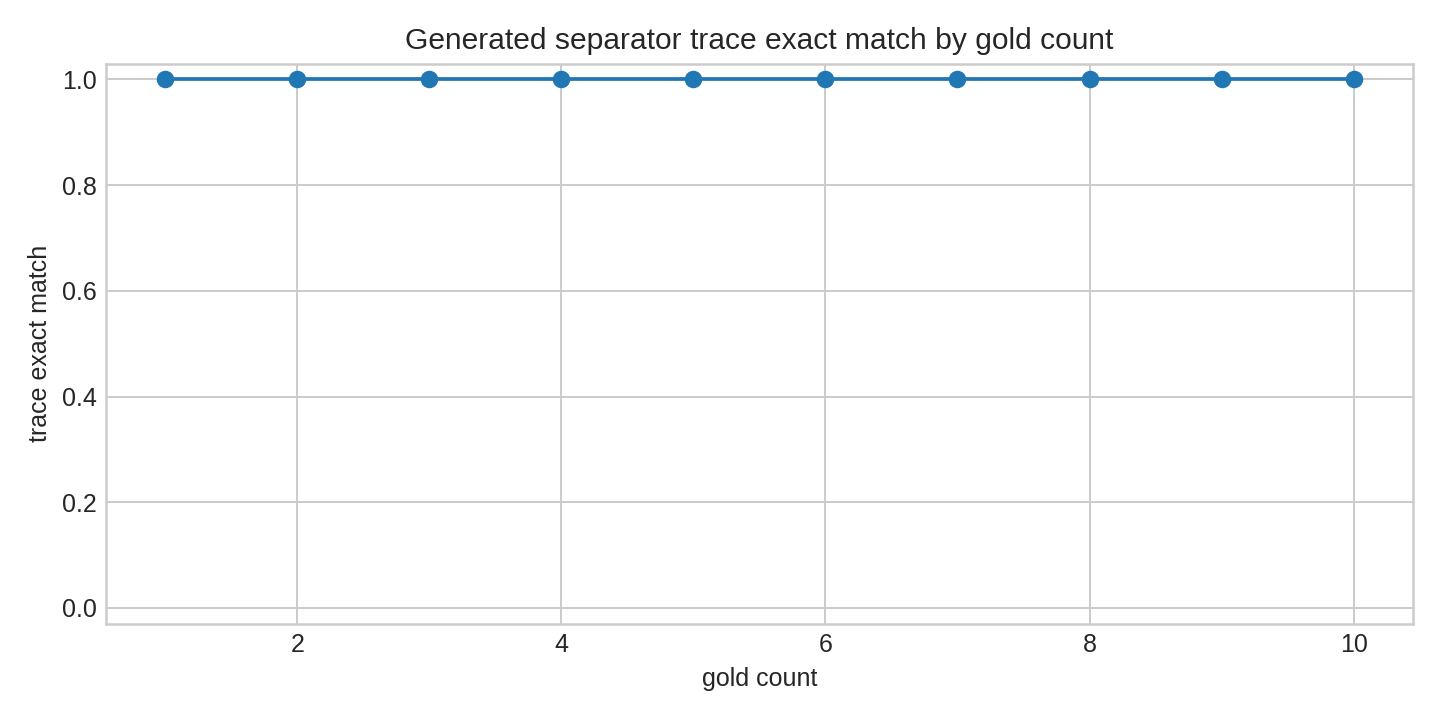

**plots/trace_delimiter_count_accuracy_by_count.png**  
x = gold count; y = rate that number of generated `<Sep>` delimiters equals the true count.

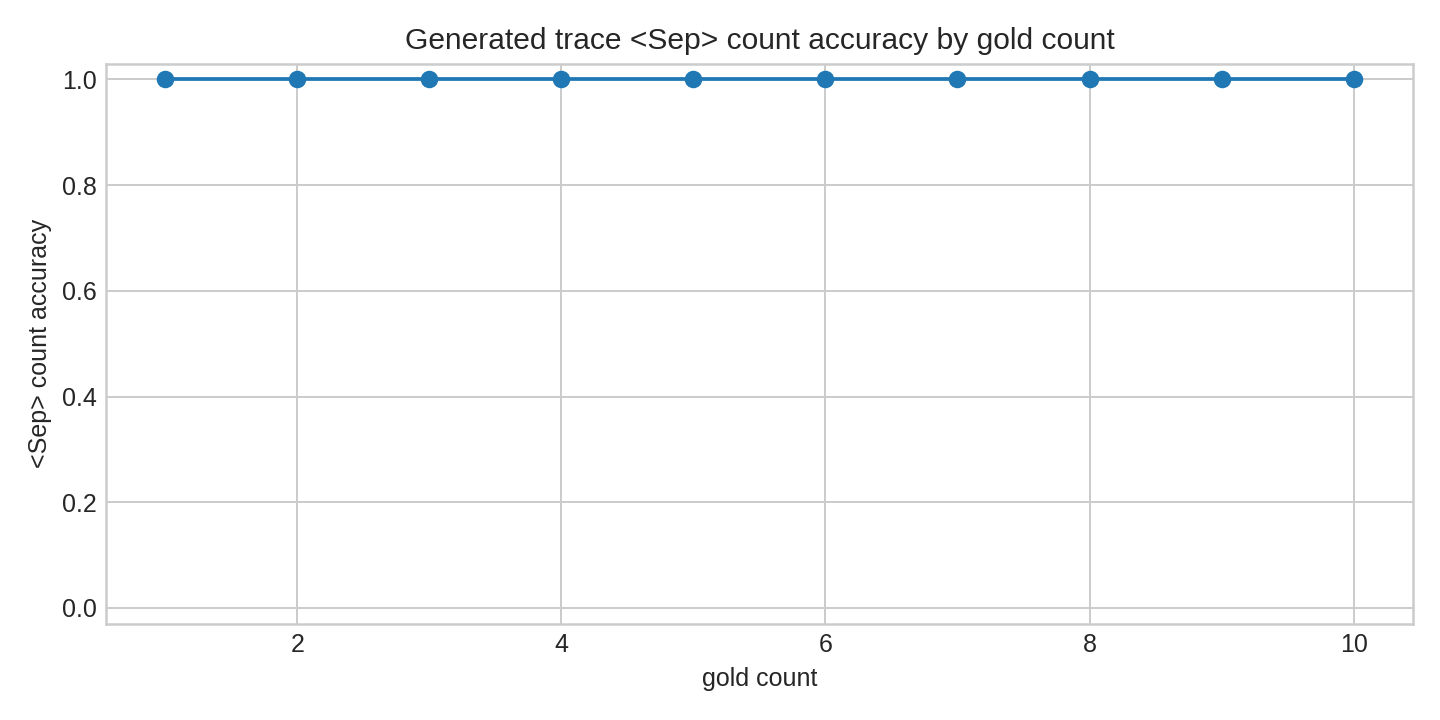

**attention/attention_thinking_sep_correct_top1_by_layer_head.png**  
Separator-thinking attention: rows = layer, columns = head, color = whether sep_token_k attends most to kth prompt needle.

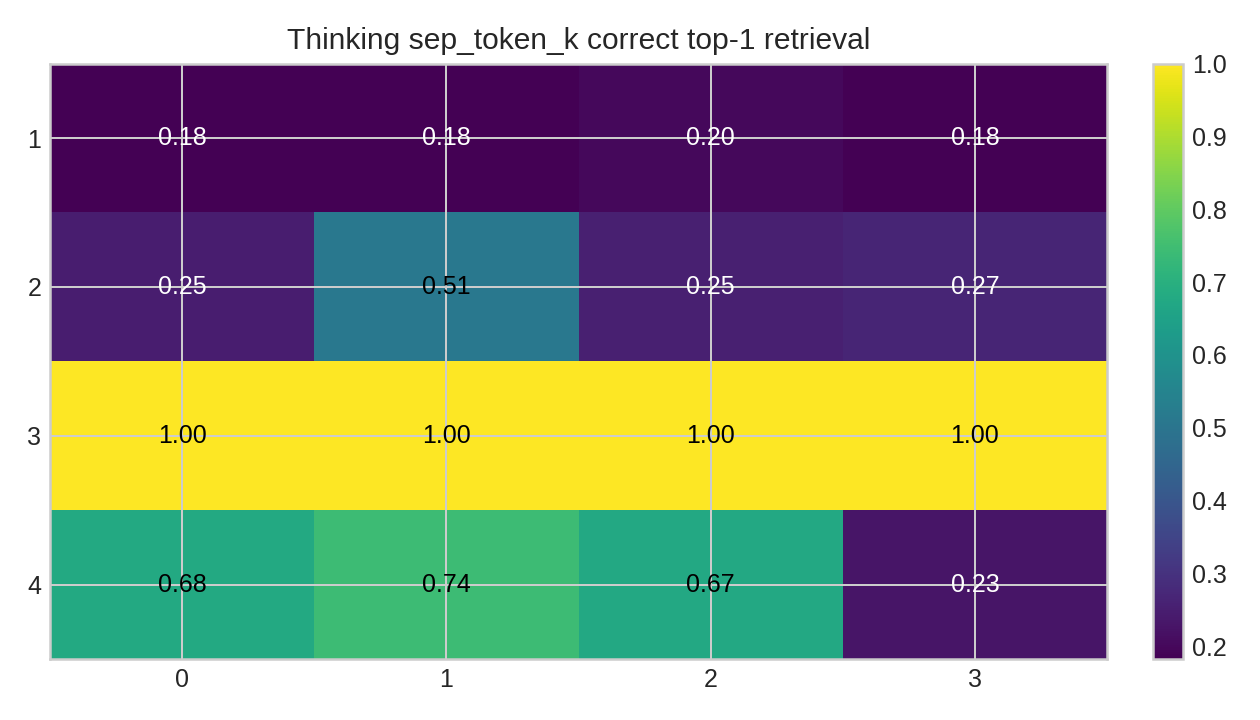

**attention/attention_matrix_thinking_sep_best_head_mid.png**  
Best separator retrieval head: x = prompt needle index j, y = trace item index k, color = average attention mass.

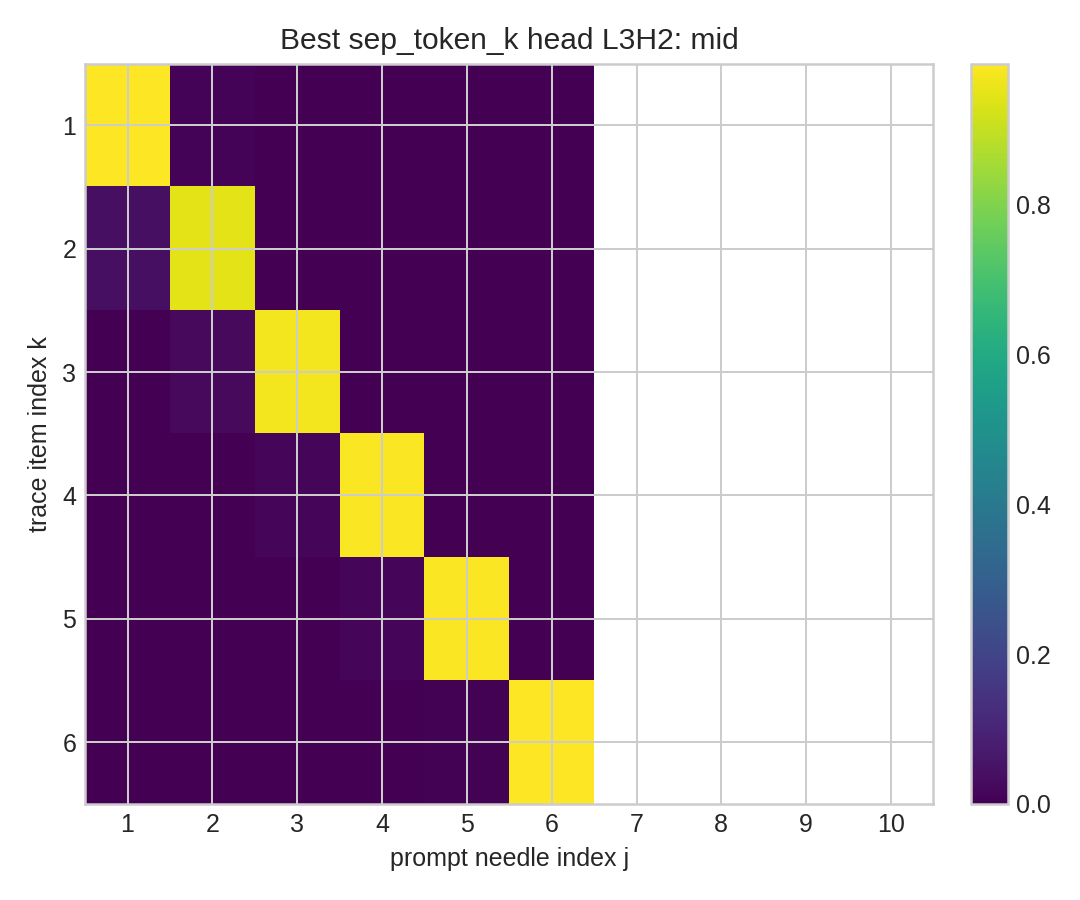

**probes/probe_prefix_count_accuracy_heatmap_thinking_sep_trace.png**  
Probe heatmap: x = layer, y = trace anchor, color = linear decodability of prefix count k.

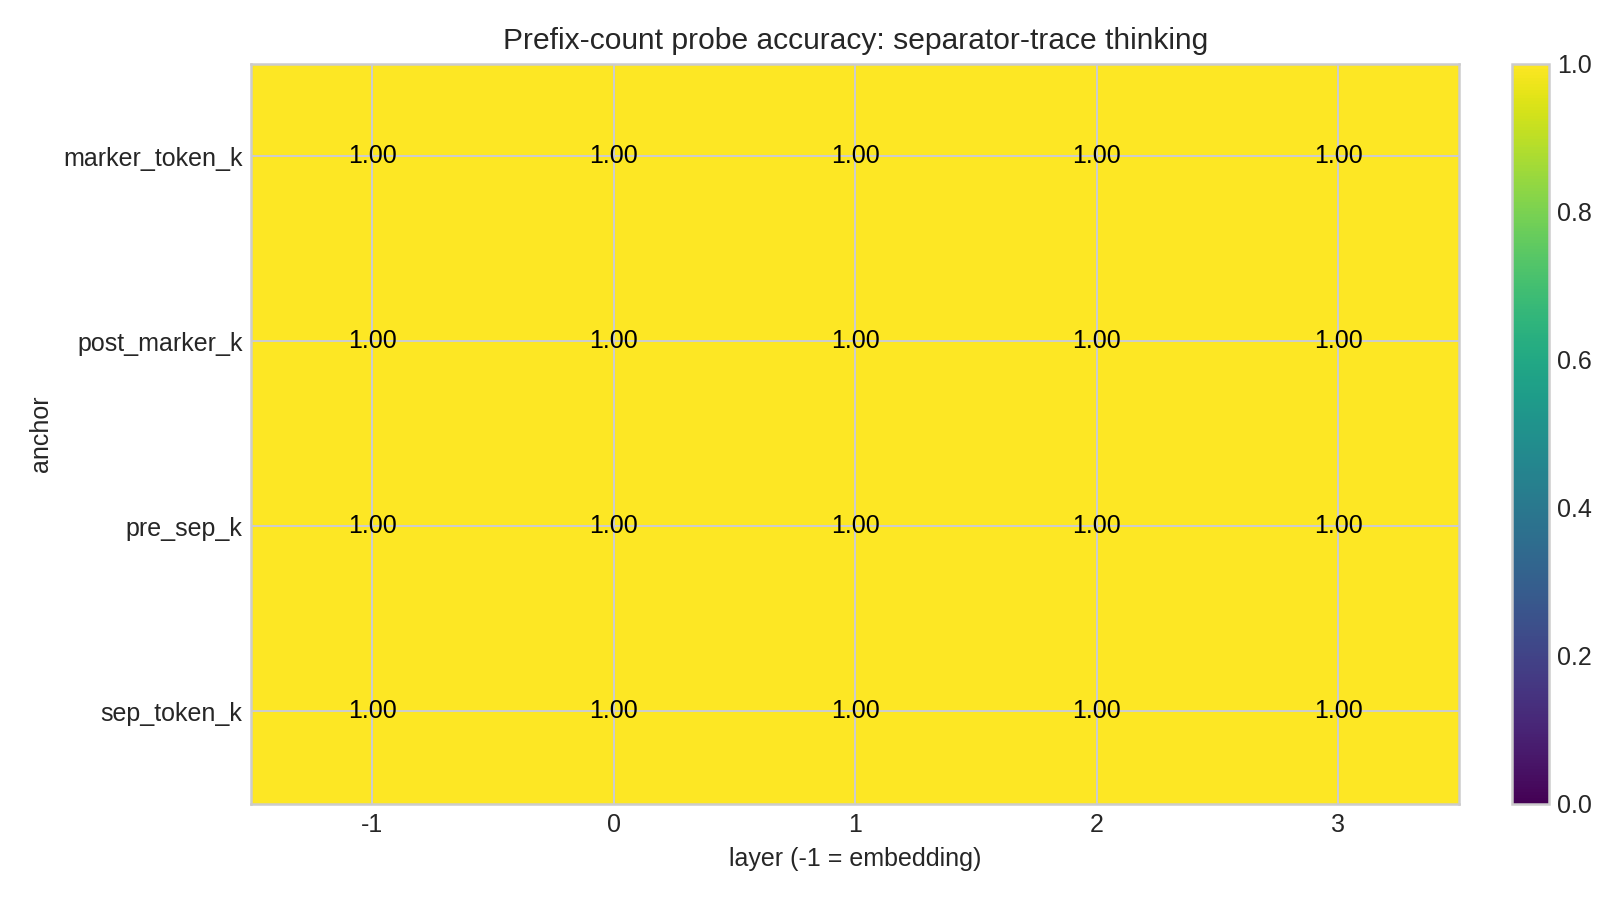

**probes/probe_sep_token_prefix_probe_minus_position_baseline.png**  
x = layer; y = sep_token_k prefix probe accuracy minus position-only baseline. Positive value suggests information beyond absolute position.

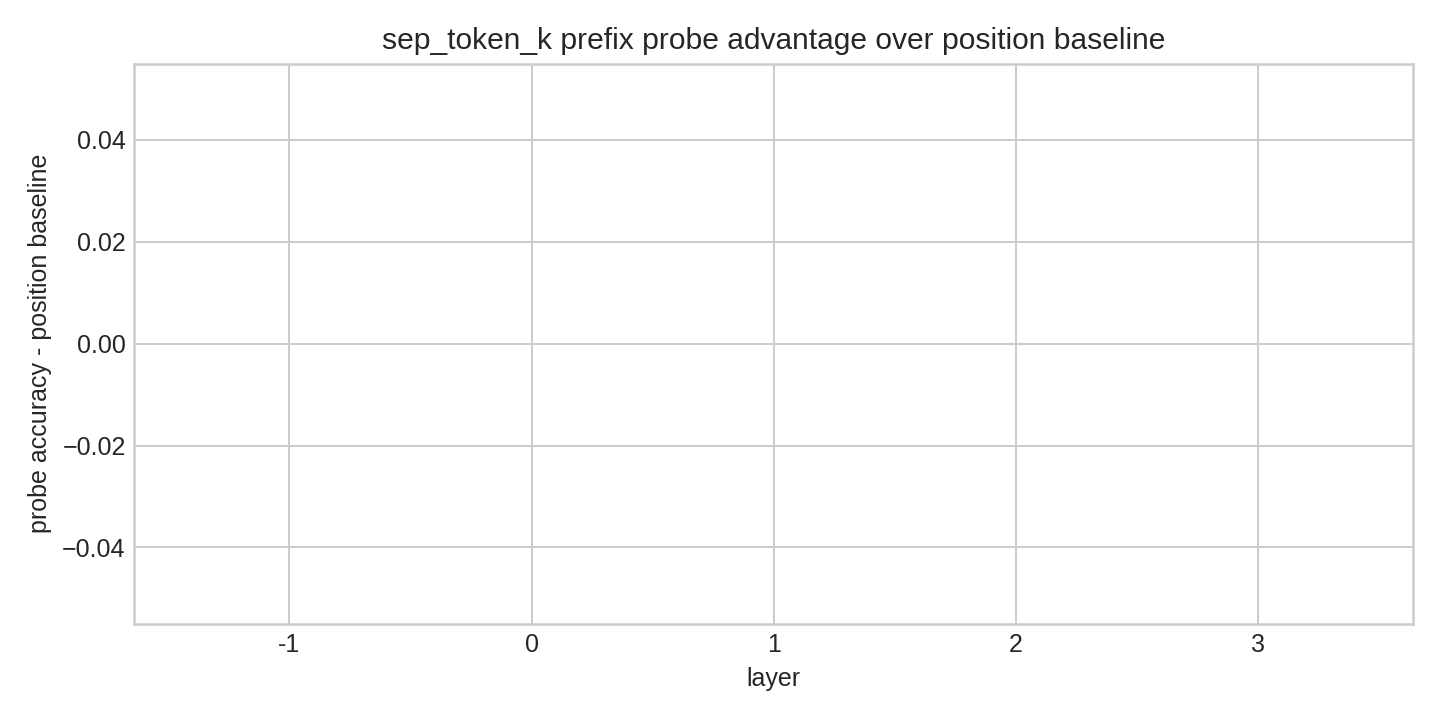

In [5]:
figure_specs = [
    ("plots/train_loss_vs_step.png", "x = training step; y = masked completion loss. Non-thinking supervises only final answer/EOS; separator-thinking supervises trace + final answer, so raw completion loss lengths differ."),
    ("plots/eval_final_answer_loss_vs_step.png", "x = training step; y = final-answer cross-entropy restricted to numeric answer tokens. This is the most comparable loss curve."),
    ("plots/eval_accuracy_by_bin_vs_step.png", "x = training step; y = exact final-count accuracy. Groups are model/eval mode/count bin: low=1-3, mid=4-6, high=7-10."),
    ("plots/final_accuracy_by_count.png", "x = gold count 1-10; y = exact final-count accuracy at final checkpoint. Groups compare direct non-thinking, generated separator trace, and oracle trace readout."),
    ("plots/accuracy_heatmap_by_count_and_step_non_thinking.png", "Non-thinking heatmap: x = training step, y = gold count, color = exact final-count accuracy."),
    ("plots/accuracy_heatmap_by_count_and_step_thinking_generated_trace.png", "Generated separator trace heatmap: x = training step, y = gold count, color = exact final-count accuracy after free generation."),
    ("plots/accuracy_heatmap_by_count_and_step_thinking_oracle_trace.png", "Oracle separator trace heatmap: x = training step, y = gold count, color = final readout accuracy when gold trace is supplied."),
    ("plots/trace_exact_by_count.png", "x = gold count; y = rate that generated trace exactly equals `<Sep> marker_1 ... <Sep> marker_n`."),
    ("plots/trace_delimiter_count_accuracy_by_count.png", "x = gold count; y = rate that number of generated `<Sep>` delimiters equals the true count."),
    ("attention/attention_thinking_sep_correct_top1_by_layer_head.png", "Separator-thinking attention: rows = layer, columns = head, color = whether sep_token_k attends most to kth prompt needle."),
    ("attention/attention_matrix_thinking_sep_best_head_mid.png", "Best separator retrieval head: x = prompt needle index j, y = trace item index k, color = average attention mass."),
    ("probes/probe_prefix_count_accuracy_heatmap_thinking_sep_trace.png", "Probe heatmap: x = layer, y = trace anchor, color = linear decodability of prefix count k."),
    ("probes/probe_sep_token_prefix_probe_minus_position_baseline.png", "x = layer; y = sep_token_k prefix probe accuracy minus position-only baseline. Positive value suggests information beyond absolute position."),
]
for rel, caption in figure_specs:
    path = RUN_DIR_PATH / rel
    if path.exists():
        display(Markdown(f"**{rel}**  \n{caption}"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Missing `{rel}`"))


## 6. Interpretation Notes

- If `thinking_sep_trace / generated_trace` reaches high final accuracy and high trace exactness, repeated `<Sep>` delimiters are enough; v2's numeric trace indices were not necessary for the main behavior.
- If oracle trace final readout is high but generated trace accuracy is low, the model can read count from a correct trace but struggles to generate the de-indexed trace.
- If `sep_token_k` has diagonal attention to the kth prompt needle, that is the v6 analogue of v2's targeted retrieval head.
- If prefix-count probe accuracy disappears after subtracting the position-only baseline, do not interpret it as a clean counter direction; trace position can still leak k even without numeric trace tokens.


## 7. Save Results to Google Drive


In [6]:
SAVE_TO_DRIVE = True
DRIVE_DEST_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results")

if SAVE_TO_DRIVE and Path("/content").exists():
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    dest = DRIVE_DEST_ROOT / f"v6_separator_trace_{PRESET}_seed1234_{timestamp}"
    dest.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(RUN_DIR_PATH, dest, dirs_exist_ok=True)
    display(Markdown(f"Saved results to Google Drive: `{dest}`"))
else:
    display(Markdown(f"SAVE_TO_DRIVE skipped. Local run dir: `{RUN_DIR_PATH}`"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saved results to Google Drive: `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v6_separator_trace_main_seed1234_20260708_175919`

## 8. Optional Auto-Disconnect Runtime


In [8]:
AUTO_DISCONNECT_AFTER_SAVE = True

if AUTO_DISCONNECT_AFTER_SAVE and Path("/content").exists():
    try:
        from google.colab import runtime
        runtime.unassign()
    except Exception as exc:
        print("Could not auto-disconnect runtime:", exc)
else:
    print("Auto-disconnect skipped.")
